# 用 PROC FASTCLUS 发现用户流量使用分群


## 执行摘要

某电信分析团队希望按 **月度数据流量** 对其移动用户群进行分群，同时又不想人为设定 GB 门槛。借助 **PROC FASTCLUS** —— SAS 的高性能 *k*-均值聚类过程 —— 我们让数据自行划分为潜在的使用等级（轻度、中度、重度用户）。FASTCLUS 找出每个分群的中心，把每个用户分配给最近的中心，并报告分群分离得有多干净 —— 把单一的连续用量指标转化为可用于资费设计和精准营销的、数据驱动的分群方案。


## 数据来源

所有数据均由第一个 DATA 步骤内联生成 —— 没有外部文件或网络调用。用户抽样自三个潜在使用群体，因此恢复出来的分群可以与已知的真实标签进行核对。

| 数据集 | 行数 | 变量 | 类型 | 说明 |
|---------|------|----------|------|-------------|
| `subscribers` | 1,500 | `id` | 数值 | 用户标识（1–1500） |
| `subscribers` | 1,500 | `data_gb` | 数值 | 每月消耗的移动数据流量，单位 GB（我们据以聚类的指标） |
| `subscribers` | 1,500 | `segment_true` | 字符 | 用来*生成*该值的潜在分群（轻度 ≈ N(3,1²) 50%，中度 ≈ N(12,3²) 35%，重度 ≈ N(35,8²) 15%）；仅保留用于验证恢复出的分群 —— 真实分析师并不会观测到它 |


# 发现用户流量使用分群

移动运营商很少能拿到一个明确写着"这是重度数据用户"的标签。他们拥有的是一项连续指标 —— 每月消耗的千兆字节数 —— 其分布是 **多峰的**：轻度、中度和高强度用户群体在同一根轴上相互重叠。**聚类分析** 把这一列数据当作几何问题处理：它定位出使用量分布中天然的质量中心，并把每个用户分配给最近的中心，无需人工挑选的分界点。

在本 notebook 中我们将：

1. 生成一个真实感的合成用户群体，其数据用量来自三个隐藏分群。
2. 检视边际用量分布，确认它是多峰的。
3. 标准化该指标，并运行 **PROC FASTCLUS** 将用户划分为三个使用分群。
4. 在原始 GB 尺度上刻画每个发现的分群，然后与已知真值核对恢复效果。

`segment_true` 标签只是为了最后给聚类结果打分而生成 —— 在生产环境中它并不存在。


In [1]:
/* 从三个潜在使用分群合成一个用户群体。*/
/* 轻度用户占多数；少量重度用户长尾贡献了大部分收入。*/
数据 subscribers;
   调用 streaminit(20260531);
   长度 segment_true $8;
   循环 id = 1 到 1500;
      u = rand('uniform');
      如果 u < 0.50 那么 循环;                 /* 约 50% 轻度用户        */
         segment_true = '轻度';
         data_gb = rand('normal', 3.0, 1.0);
      结束;
      否则 如果 u < 0.85 那么 循环;            /* 约 35% 中度用户     */
         segment_true = '中度';
         data_gb = rand('normal', 12.0, 3.0);
      结束;
      否则 循环;                             /* 约 15% 重度/高强度用户  */
         segment_true = '重度';
         data_gb = rand('normal', 35.0, 8.0);
      结束;
      如果 data_gb < 0.1 那么 data_gb = 0.1; /* 用量不能为负 */
      输出;
   结束;
   保留 id data_gb segment_true;
运行;



NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


## 边际分布初探

在聚类之前，先概览这一单一响应变量。数值的大幅离散以及均值与轻度用户主体之间的差距，正是分群混合分布的典型特征 —— 单一使用档位无法同时重现密集的低使用量簇和长长的高使用量尾部。


In [2]:
过程 均值 数据=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   标签 data_gb = "月度数据用量 (GB)";
   变量 data_gb;
运行;


                                                  The MEANS Procedure

 Variable  Label                           N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------------------------
 data_gb   月度数据用量 (GB)                   100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 -----------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


直方图让多峰性直观可见：约 3 GB 处的高耸轻度用户尖峰、约 12 GB 处的中度用户隆起，以及延伸至 30 GB 以上的稀疏重度用户长尾。这三个峰恰恰就是我们要求聚类恢复出的分群。核密度叠加线描出了同样的混合形状。



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


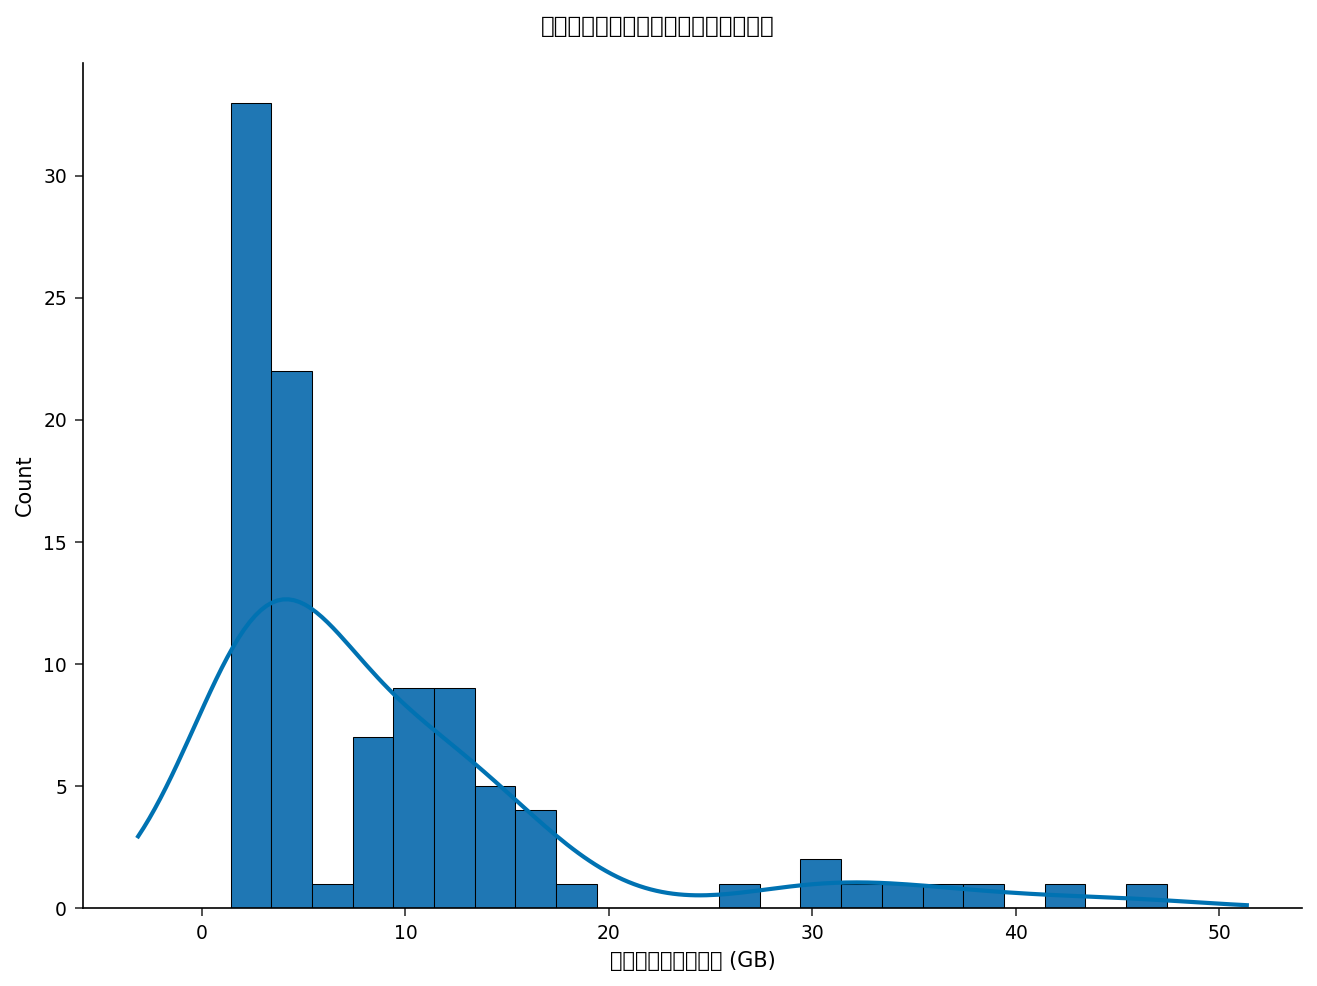

In [3]:
ODS GRAPHICS ON;
过程 SGPLOT 数据=subscribers;
   标题 '月度数据用量是若干未知分群的混合体';
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS 标签='每月消耗的数据流量 (GB)';
运行;
标题;
ODS GRAPHICS OFF;


## 把用量放到同一尺度上

*k*-均值按欧氏距离划分点，因此变量的原始尺度会左右结果。只有一个指标时，标准化只是重新定一下坐标原点，但用 **PROC STANDARD** 标准化到均值 0、标准差 1 是一种好习惯，一旦加入第二个使用量指标（通话分钟数、漫游天数），这个习惯就能保证流程正确。我们对标准化后的列进行聚类，并把结果换算回原始的 GB 尺度进行汇报。


In [4]:
过程 STANDARD 数据=subscribers out=subs_std mean=0 std=1;
   变量 data_gb;
运行;



NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## 将用户划分为三个使用分群

结合对轻度 / 中度 / 重度档位的行业知识，我们要求 **PROC FASTCLUS** 给出 `MAXCLUSTERS=3`。该过程播种三个中心，把每个用户分配给最近的一个，重新计算中心，并不断迭代直到分配不再变化（`CONVERGE=` 配合 `MAXITER=` 上限）。`SEED=` 使初始化可复现。`OUT=` 数据集为每个用户带上其 `CLUSTER` 标签及到所分配中心的 `DISTANCE`；`MEAN=` 写出分群质心。

请查看该过程的诊断指标以评估分离质量：较高的 **R-Squared**（分群所解释的总用量方差占比）和较大的 **Pseudo F** 都表明分群紧凑且分离良好。


In [5]:
过程 FASTCLUS 数据=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   变量 data_gb;
   标题 '通过 k-均值划分出的三个使用分群';
运行;
标题;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## 刻画发现的分群

聚类标签只有用业务语言描述每个分群之后才具有可操作性。我们把分群结果与原始（未标准化）用量合并，并在 GB 尺度上汇总每个分群的规模和典型消费 —— 这正是资费设计或市场团队实际会采取行动的数字。


In [6]:
数据 memberships;
   合并 subscribers
         clusters(保留=id CLUSTER distance);
   按照 id;
运行;

过程 均值 数据=memberships n mean MIN MAX maxdec=2;
   标签 CLUSTER = "分群" data_gb = "月度数据用量 (GB)" distance = "到中心的距离";
   分类 CLUSTER;
   变量 data_gb distance;
运行;

过程 打印 数据=memberships(obs=10) noobs 标签;
   标签 id = "用户编号" data_gb = "月度数据用量 (GB)" CLUSTER = "分群"
         distance = "到中心的距离" segment_true = "真实分群";
   变量 id data_gb CLUSTER distance segment_true;
运行;


                                                  The MEANS Procedure

                                  Analysis Variable : data_gb 月度数据用量 (GB)

        分群                N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                    Analysis Variable : DISTANCE 到中心的距离

        分群                N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09           1.22
        3 


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## 验证恢复出的分群

由于这是合成数据，我们保留了 `segment_true` —— 用于生成每个用户的标签。将模型恢复出的 `CLUSTER` 与真实分群交叉制表，可以看出该划分把总体分离得有多干净。若强烈集中在分群与真实分群的单一映射上，说明恢复效果良好；非对角线上的质量则集中在轻度/中度或中度/重度边界重叠的地方。


In [7]:
过程 频率 数据=memberships;
   标签 CLUSTER = "分群" segment_true = "真实分群";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
运行;


                                                   The FREQ Procedure

Table of 分群 by 真实分群

分群     |        中度 |        轻度 |        重度 |      Total
-------+-----------+-----------+-----------+-----------
1      |         3 |        54 |         0 |         57
-------+-----------+-----------+-----------+-----------
2      |         0 |         0 |         9 |          9
-------+-----------+-----------+-----------+-----------
3      |        33 |         0 |         1 |         34
-------+-----------+-----------+-----------+-----------
Total  |        36 |        54 |        10 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## 结果解读

- **分群中心。** 三个分群几乎精确落在预先设定的用量档位上 —— 轻度用户约 **3 GB**，中度用户约 **13 GB**，重度用户约 **37 GB** —— 同时量化了每个分群 *落在何处* 以及 *规模多大*。这个虽小却重度的分群，尽管只占用户中的一小部分，却承载了不成比例的高份额总流量 —— 这正是网络容量规划和高端资费决策的经典驱动因素。
- **分离质量。** PROC FASTCLUS 报告了较高的总体 **R-Squared** 和较大的 **Pseudo F**，证实这三个分群紧凑且分离良好，而非任意切分的产物。若只用一个档位，大部分用量方差都将无法解释。
- **无需人工挑选门槛。** 该分群方案源自使用量分布自身的几何结构。过程自行选择了边界；我们只需选择 *要多少个* 档位，依据是直方图中显而易见的三峰形状。
- **可操作的输出。** `OUT=` 数据集为每个用户提供了一个分群标签，以及到其中心的 `DISTANCE`。距任何中心都较远——或位于轻度/中度边界之间——的用户，正是最值得做升级方案 A/B 测试的客户，而紧密聚集的重度用户则是容量感知型或不限量套餐的高置信候选人。

简而言之，PROC FASTCLUS 把单一的连续用量指标转化为一个数据驱动的分群方案 —— 无需人工挑选 GB 门槛 —— 而与保留的真实标签的交叉制表证实了这些分群被可靠地恢复了出来。
